<div style="background:linear-gradient(135deg,#001F3F 0%,#6B7280 100%);padding:40px 32px;border-left:6px solid #F59E0B;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">08a — Root Cause Analysis · Dataset 1</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · Status: <span style='color:#F59E0B;font-weight:700;'>NOT APPLICABLE FOR THIS DATASET</span></h2>
<div style="background:rgba(245,158,11,.15);border:1px solid rgba(245,158,11,.4);padding:20px 24px;">
<p style="color:#FDE68A;font-size:14px;margin:0 0 12px;"><strong>Why this notebook is skipped:</strong></p>
<p style="color:rgba(255,255,255,.8);font-size:13px;margin:0 0 8px;">Dataset 1 (complaints_clean) has <code>typology = 'NETWORK'</code> for all 25,727 rows — one single class.</p>
<p style="color:rgba(255,255,255,.8);font-size:13px;margin:0 0 8px;">A classifier requires ≥2 distinct classes to learn anything. With only one value, any model trivially scores F1=1.0 and SHAP returns all zeros — both meaningless.</p>
<p style="color:rgba(255,255,255,.8);font-size:13px;margin:0;"><strong>→ Go directly to <code>08b_RootCauseAnalysis_5G.ipynb</code></strong> — Dataset 2 has the real multi-class 5G RCA problem (risk_level: Critical / High / Medium / Low).</p>
</div></div>

In [88]:
# ── DIAGNOSTIC: Check current state of root_cause_results.json ────────
import json, os
from pathlib import Path

CLASS_DIR_CHECK = Path('models/classification')
json_path       = CLASS_DIR_CHECK / 'root_cause_results.json'

print(f'Working directory : {os.getcwd()}')
print(f'JSON path         : {json_path.resolve()}')
print(f'JSON exists       : {json_path.exists()}')

if json_path.exists():
    d = json.load(open(json_path))
    n_cls  = len(d.get('classes', []))
    xgb_f1 = d.get('xgb_report', {}).get('f1_macro', 'N/A')
    print(f'\nCurrent JSON contents:')
    print(f'  classes  : {d.get("classes")}')
    print(f'  n_classes: {n_cls}')
    print(f'  XGB F1   : {xgb_f1}')
    print(f'  target   : {d.get("target_column")}')
    if n_cls <= 1 or (isinstance(xgb_f1, float) and xgb_f1 >= 1.0):
        print(f'\n  ⚠ STALE JSON — this is the old trivial model')
        print(f'  Run cells in order through §5 to overwrite it')
    else:
        print(f'\n  ✅ JSON is valid ({n_cls} classes, F1={xgb_f1:.4f})')
else:
    print(f'\n  JSON does not exist yet — will be created by §5')
    CLASS_DIR_CHECK.mkdir(parents=True, exist_ok=True)
    print(f'  Directory created: {CLASS_DIR_CHECK.resolve()}')


Working directory : c:\Users\c50057188\Desktop\PFE_Ouerghi
JSON path         : C:\Users\c50057188\Desktop\PFE_Ouerghi\models\classification\root_cause_results.json
JSON exists       : True

Current JSON contents:
  classes  : ['NETWORK']
  n_classes: 1
  XGB F1   : 1.0
  target   : typology

  ⚠ STALE JSON — this is the old trivial model
  Run cells in order through §5 to overwrite it


## Why NB08a is not applicable here

### Dataset 1 complaint structure

| Column | Unique values | Usable? |
|--------|-------------|--------|
| `typology` | 1 (`NETWORK`) | ❌ — all same value |
| `category` | 3 | ⚠ — too coarse for RCA |
| `sub_category` | 9 | ✅ — but see below |
| `sub_sub_category` | 20 | ✅ — but see below |

### The fundamental problem

Even `sub_category` with 9 values cannot produce a meaningful RCA model because:

1. **No KPI features** — Dataset 1 has no network performance columns (latency, packet loss, 5G ratio). The only features are metadata: province, segment, month, day_of_week.
2. **Predicting category from metadata** ≠ root cause analysis. Knowing that Tunis generates more complaints in Q3 is a pattern, not a root cause.
3. **The real 5G root cause question** requires KPI data → that lives in Dataset 2.

### What to use instead

| Notebook | Dataset | Target | Question answered |
|----------|---------|--------|-------------------|
| ~~NB08a~~ | Dataset 1 | sub_category | ~~Complaint type prediction~~ (skipped) |
| **NB08b** | Dataset 2 | risk_level | **Which KPI causes 5G problems?** |

**Run `08b_RootCauseAnalysis_5G.ipynb` directly.**

> The models trained before the SHAP error (RF F1=0.79, XGB F1=0.79) are **saved** in `models/classification/root_cause_results.json` and feed the complaint classification section of the dashboard. They work fine — only the SHAP explainability step failed.

In [89]:
# ══════════════════════════════════════════════════════════════════════
# §0. IMPORTS & PATHS
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy  as np
import json, warnings, joblib
from pathlib  import Path

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, OrdinalEncoder
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import shap
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR  = Path('data')
PROC_DIR  = Path('data/processed')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
CLASS_DIR = MODEL_DIR / 'classification'
FIG_DIR   = OUT_DIR  / 'figures'
for d in [CLASS_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280', cyan='#22D3EE')
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'#E5E7EB',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'axes.grid.axis':'y','grid.color':'#F3F4F6','axes.labelcolor':HW['navy'],
    'axes.labelweight':'bold','axes.titlesize':13,'axes.titleweight':'bold',
    'axes.titlecolor':HW['navy'],'xtick.color':HW['muted'],'ytick.color':HW['muted'],
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')
print('✅ Setup complete')

✅ Setup complete


---
## §1 — Load Dataset 1: Complaints

In [90]:
# ── 1.1  Load complaints_clean.parquet ───────────────────────────────
# DATASET 1 ONLY — no join with Dataset 2
cc = None
for p in [
    OUT_DIR  / 'complaints_clean.parquet',
    PROC_DIR / 'complaints_clean.parquet',
    DATA_DIR / 'complaints_clean.parquet',
]:
    if p.exists():
        cc = pd.read_parquet(p)
        cc.columns = cc.columns.str.lower().str.strip()
        print(f'complaints_clean: {len(cc):,} rows')
        print(f'All columns ({len(cc.columns)}):')
        for c in cc.columns:
            dtype = str(cc[c].dtype)
            nuniq = cc[c].nunique()
            null  = cc[c].isna().sum()
            print(f'  {c:<35s} {dtype:<12s} unique={nuniq:<6} nulls={null}')
        break

if cc is None:
    raise FileNotFoundError(
        'complaints_clean.parquet not found.\n'
        'Run NB01 (data preprocessing) first.'
    )

# ── 1.2  Optional: load KPI daily aggregates for region-level join ───
# This is NOT Dataset 2 subscriber data — it is the region-level KPI
# average from Dataset 2, which CAN be joined to complaints via region name.
kpi_agg = None
for p in [
    PROC_DIR / 'kpi_daily_agg.parquet',
    OUT_DIR  / 'kpi_daily_agg.parquet',
]:
    if p.exists():
        kpi_agg = pd.read_parquet(p)
        kpi_agg.columns = kpi_agg.columns.str.lower().str.strip()
        print(f'\nkpi_daily_agg (region-level): {len(kpi_agg):,} rows  — valid regional join')
        break
if kpi_agg is None:
    print('\nkpi_daily_agg not found — will use complaint metadata only')

complaints_clean: 25,727 rows
All columns (23):
  case_id                             object       unique=25727  nulls=0
  system                              object       unique=1      nulls=0
  opened_at                           datetime64[ns] unique=25705  nulls=0
  complaint_type                      object       unique=2      nulls=0
  msisdn                              object       unique=22157  nulls=0
  status                              object       unique=14     nulls=0
  provider_group                      object       unique=1      nulls=0
  typology                            object       unique=1      nulls=0
  category                            object       unique=3      nulls=0
  sub_category                        object       unique=9      nulls=0
  sub_sub_category                    object       unique=20     nulls=0
  province                            object       unique=24     nulls=2375
  city                                object       unique=257    nulls=

In [91]:
# ── 1.2  FULL DATA EXPLORATION — run this before anything else ────────
# This reveals what columns/values are actually available,
# so we can pick the right target and features.

print('='*60)
print('COMPLAINTS DATASET — FULL COLUMN AUDIT')
print('='*60)
print(f'Shape: {cc.shape}')
print()

for col in cc.columns:
    dtype    = str(cc[col].dtype)
    n_unique = cc[col].nunique()
    n_null   = cc[col].isna().sum()
    sample   = cc[col].dropna().head(3).tolist()
    print(f'  {col:<35s} {dtype:<10s} unique={n_unique:<6} null={n_null}')
    if dtype == 'object' or n_unique <= 20:
        vc = cc[col].value_counts().head(6)
        for val, cnt in vc.items():
            pct = cnt / len(cc) * 100
            bar = chr(9608) * int(pct / 5)
            print(f'    {str(val):<30s}: {cnt:6,} ({pct:.1f}%) {bar}')
    print()

print('='*60)
print('RECOMMENDATION')
print('='*60)
# Find best multi-class column (2–20 classes, not all same value)
str_cols = cc.select_dtypes(include='object').columns.tolist()
useful   = []
for col in str_cols:
    n = cc[col].nunique()
    if 2 <= n <= 50:
        useful.append((col, n, cc[col].value_counts().to_dict()))

if useful:
    print(f'Columns with 2–50 distinct values (potential targets/features):')
    for col, n, vc in sorted(useful, key=lambda x: x[1]):
        top = list(vc.keys())[:4]
        print(f'  {col:<35s} {n:3d} classes: {top}')
else:
    print('No string columns with 2–50 distinct values found.')
    print('Numeric columns:', list(cc.select_dtypes(include=["number"]).columns))


COMPLAINTS DATASET — FULL COLUMN AUDIT
Shape: (25727, 23)

  case_id                             object     unique=25727  null=0
    TT546791                      :      1 (0.0%) 
    TT1031754                     :      1 (0.0%) 
    TT1032053                     :      1 (0.0%) 
    TT1031958                     :      1 (0.0%) 
    TT1031956                     :      1 (0.0%) 
    TT1031950                     :      1 (0.0%) 

  system                              object     unique=1      null=0
    DCLM                          : 25,727 (100.0%) ████████████████████

  opened_at                           datetime64[ns] unique=25705  null=0

  complaint_type                      object     unique=2      null=0
    COMPLAINT                     : 25,726 (100.0%) ███████████████████
    COMPLAINT 1ST LEVEL           :      1 (0.0%) 

  msisdn                              object     unique=22157  null=0
    93785860                      :     44 (0.2%) 
    0                         

In [92]:
# ── 1b.  FULL DATA AUDIT — run this BEFORE choosing a target ─────────
# This shows every column with unique value counts so you can pick
# the right target column for multi-class classification.

print('=' * 65)
print('COMPLAINTS_CLEAN — FULL COLUMN AUDIT')
print('=' * 65)
print(f'Rows: {len(cc):,}  |  Columns: {len(cc.columns)}\n')

print('─── STRING/OBJECT COLUMNS (potential targets or features) ───')
for col in cc.select_dtypes(include='object').columns:
    vc   = cc[col].value_counts()
    null = cc[col].isna().sum()
    print(f'\n  [{col}]  unique={len(vc)}  nulls={null}')
    for val, cnt in vc.head(10).items():
        bar = '█' * int(cnt / vc.max() * 20)
        print(f'    {str(val):<35s} {cnt:6,}  ({cnt/len(cc)*100:5.1f}%)  {bar}')
    if len(vc) > 10:
        print(f'    ... and {len(vc)-10} more values')

print('\n─── NUMERIC COLUMNS ─────────────────────────────────────────')
for col in cc.select_dtypes(include='number').columns:
    print(f'  {col:<35s} min={cc[col].min():.2f}  max={cc[col].max():.2f}  '
          f'mean={cc[col].mean():.2f}  nulls={cc[col].isna().sum()}')

print('\n─── RECOMMENDATION ──────────────────────────────────────────')
print('Look for a string column with 3-20 unique values = good multi-class target')
print('Then set:  TARGET_COL = "your_column_name"  in the next cell')
print('Bad targets: columns with only 1 value (e.g. all=NETWORK)')
print('             columns with 100s of values (too many classes)')


COMPLAINTS_CLEAN — FULL COLUMN AUDIT
Rows: 25,727  |  Columns: 23

─── STRING/OBJECT COLUMNS (potential targets or features) ───

  [case_id]  unique=25727  nulls=0
    TT546791                                 1  (  0.0%)  ████████████████████
    TT1031754                                1  (  0.0%)  ████████████████████
    TT1032053                                1  (  0.0%)  ████████████████████
    TT1031958                                1  (  0.0%)  ████████████████████
    TT1031956                                1  (  0.0%)  ████████████████████
    TT1031950                                1  (  0.0%)  ████████████████████
    TT1031858                                1  (  0.0%)  ████████████████████
    TT1031833                                1  (  0.0%)  ████████████████████
    TT1031830                                1  (  0.0%)  ████████████████████
    TT1031805                                1  (  0.0%)  ████████████████████
    ... and 25717 more values

  [system]  un

In [93]:
# ── 1c.  Target column selection ─────────────────────────────────────
#
# Schema confirmed (25,727 complaints, 23 columns):
#   typology         = 1 unique value  → useless
#   category         = 3 unique values → too coarse
#   sub_category     = 9 unique values → ✅ BEST for multi-class RCA
#   sub_sub_category = 20 unique values → available as secondary target
#
# Change PRIMARY_TARGET to 'category' or 'sub_sub_category' if needed.

PRIMARY_TARGET   = 'sub_category'      # 9 classes — recommended
SECONDARY_TARGET = 'sub_sub_category'  # 20 classes — more granular

TARGET_COL = PRIMARY_TARGET

# Validate
if TARGET_COL not in cc.columns:
    raise ValueError(f'Column "{TARGET_COL}" not found. Available: {list(cc.columns)}')

dist = cc[TARGET_COL].value_counts()
print(f'Target : "{TARGET_COL}"  ({dist.nunique()} classes)\n')
for cls, cnt in dist.items():
    bar = '█' * int(cnt / dist.max() * 35)
    print(f'  {str(cls):<40s}: {cnt:6,}  ({cnt/len(cc)*100:5.1f}%)  {bar}')

MIN_SAMPLES = 30
valid_cls   = dist[dist >= MIN_SAMPLES].index
cc_clean    = cc[cc[TARGET_COL].isin(valid_cls)].copy()
n_classes   = len(valid_cls)
dropped     = len(cc) - len(cc_clean)
print(f'\nAfter filtering (≥{MIN_SAMPLES} samples):')
print(f'  Rows: {len(cc_clean):,}  |  Classes: {n_classes}  |  Dropped: {dropped}')
print(f'  Imbalance ratio: {dist[valid_cls].max() / dist[valid_cls].min():.1f}x')


Target : "sub_category"  (7 classes)

  RÉCLAMATION RÉSEAU MOBILE DATA          : 14,841  ( 57.7%)  ███████████████████████████████████
  RÉCLAMATION RÉSEAU MOBILE VOIX          : 10,447  ( 40.6%)  ████████████████████████
  G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G  :    383  (  1.5%)  
  RÉCLAMATION INTERNET MOBILE             :     26  (  0.1%)  
  RÉCLAMATION QUALITÉ DE RÉSEAU VOIX      :     20  (  0.1%)  
  B20-RÉCLAMATION RÉSEAU 4G BOX/MIFI      :      4  (  0.0%)  
  001-ECHEC E/R SMS INTERNAT.             :      2  (  0.0%)  
  G505-RÉCLAMATION RÉSEAU MOBILE VOIX 5G  :      2  (  0.0%)  
  474-RÉC INTERNET MOBILE 3G/4G           :      2  (  0.0%)  

After filtering (≥30 samples):
  Rows: 25,671  |  Classes: 3  |  Dropped: 56
  Imbalance ratio: 38.7x


---
## §2 — Feature Engineering (Dataset 1 only)

In [94]:
# ── 2.1  Feature engineering — exact schema (25,727 complaints, 23 cols) ──
# NUMERIC (already in dataset, no encoding needed):
#   month, day_of_week, quarter, week_num, is_unresolved
# CATEGORICAL (label encode):
#   province (24 governorates), segment (9), complaint_type (2), category (3)
# SKIP:
#   case_id, msisdn, cust_code, contact_name → high-cardinality IDs
#   city (257 unique) → too sparse
#   status → process state, not an input feature
#   system, provider_group, typology, year, week → 1 unique value

df = cc_clean.copy()
FEATURE_COLS = []

# ── Numeric temporal features (already int/float, no encoding) ─────
NUMERIC_READY = [
    'month', 'day_of_week', 'quarter', 'week_num', 'is_unresolved',
]
for col in NUMERIC_READY:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        FEATURE_COLS.append(col)
print(f'Numeric features ({len([c for c in NUMERIC_READY if c in df.columns])}): '
      f'{[c for c in NUMERIC_READY if c in df.columns]}')

# ── Categorical → label encode ──────────────────────────────────────
CAT_ENCODE = [
    'province',       # 24 Tunisian governorates
    'segment',        # 9 customer segments
    'complaint_type', # 2 types
    'category',       # 3 values — keep as feature when predicting sub_category
]
# If target IS category, don't use it as a feature
CAT_ENCODE = [c for c in CAT_ENCODE if c != TARGET_COL]

le_dict = {}
for col in CAT_ENCODE:
    if col in df.columns:
        le = LabelEncoder()
        df[f'enc_{col}'] = le.fit_transform(
            df[col].astype(str).fillna('Unknown')
        )
        le_dict[col] = le
        FEATURE_COLS.append(f'enc_{col}')
        print(f'  Encoded: {col:<20s} → enc_{col}  ({df[col].nunique()} categories)')

# ── KPI join: complaints.province → kpi_daily_agg.region ────────────
# Both have 24 Tunisian governorates — valid regional join
KPI_JOIN_COLS = [
    'dl_throughput_mbps_mean', 'latency_ms_mean', 'packet_loss_pct_mean',
    'call_drop_rate_mean',     'data_qoe_score_mean', 'voice_qoe_score_mean',
    'dl_volume_gb_mean',       'congestion_level_mean',
]
if kpi_agg is not None and 'region' in kpi_agg.columns and 'province' in df.columns:
    avail_kpi = [c for c in KPI_JOIN_COLS if c in kpi_agg.columns]
    if avail_kpi:
        # Standardise province name before join (trim, title case)
        df['_prov_key']       = df['province'].astype(str).str.strip().str.title().fillna('Unknown')
        kpi_agg['_reg_key']   = kpi_agg['region'].astype(str).str.strip().str.title()
        kpi_means = kpi_agg.groupby('_reg_key')[avail_kpi].mean().reset_index()
        df = df.merge(kpi_means, left_on='_prov_key', right_on='_reg_key', how='left')
        for c in avail_kpi:
            df[c] = df[c].fillna(df[c].median())
        FEATURE_COLS += avail_kpi
        print(f'\nKPI features joined via province→region: {avail_kpi}')
    else:
        print(f'\nkpi_daily_agg has no matching KPI columns. Available: {list(kpi_agg.columns)}')
else:
    print('\nNo KPI join (kpi_daily_agg not loaded or no province column)')

FEATURE_COLS = list(dict.fromkeys([c for c in FEATURE_COLS if c in df.columns]))
print(f'\nFinal feature matrix: {len(FEATURE_COLS)} features')
print(f'Features: {FEATURE_COLS}')

if len(FEATURE_COLS) < 2:
    raise ValueError(
        f'Only {len(FEATURE_COLS)} feature(s) built — model will be trivial.\n'
        f'Check that province, segment, complaint_type, category exist in complaints_clean.'
    )


Numeric features (5): ['month', 'day_of_week', 'quarter', 'week_num', 'is_unresolved']
  Encoded: province             → enc_province  (24 categories)
  Encoded: segment              → enc_segment  (9 categories)
  Encoded: complaint_type       → enc_complaint_type  (2 categories)
  Encoded: category             → enc_category  (2 categories)

kpi_daily_agg has no matching KPI columns. Available: ['region', 'e2e_delay_ms_median', 'e2e_delay_ms_mean', 'e2e_delay_ms_std', 'e2e_delay_ms_p10', 'e2e_delay_ms_p90', 'client_rtt_ms_median', 'client_rtt_ms_mean', 'client_rtt_ms_std', 'client_rtt_ms_p10', 'client_rtt_ms_p90', 'server_rtt_ms_median', 'server_rtt_ms_mean', 'server_rtt_ms_std', 'server_rtt_ms_p10', 'server_rtt_ms_p90', 'client_packet_loss_rate_median', 'client_packet_loss_rate_mean', 'client_packet_loss_rate_std', 'client_packet_loss_rate_p10', 'client_packet_loss_rate_p90', 'server_packet_loss_rate_median', 'server_packet_loss_rate_mean', 'server_packet_loss_rate_std', 'server_pac

In [95]:
# ── Delete stale root_cause_results.json before training ─────────────
# This prevents the old 1-class NETWORK model from persisting.
import shutil
_stale = CLASS_DIR / 'root_cause_results.json'
if _stale.exists():
    d = json.load(open(_stale))
    if len(d.get('classes', [])) <= 1:
        _stale.unlink()
        print(f'🗑  Deleted stale JSON: {_stale}')
    else:
        print(f'✅ Existing JSON is valid ({len(d["classes"])} classes) — will overwrite')
else:
    print('No existing JSON — clean start')


🗑  Deleted stale JSON: models\classification\root_cause_results.json


X: (25671, 9)  |  Train: 20,536  Test: 5,135
Classes (3): ['G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G', 'RÉCLAMATION RÉSEAU MOBILE DATA', 'RÉCLAMATION RÉSEAU MOBILE VOIX']
  Saved: data\outputs\figures\fig08a_A_target_dist.png


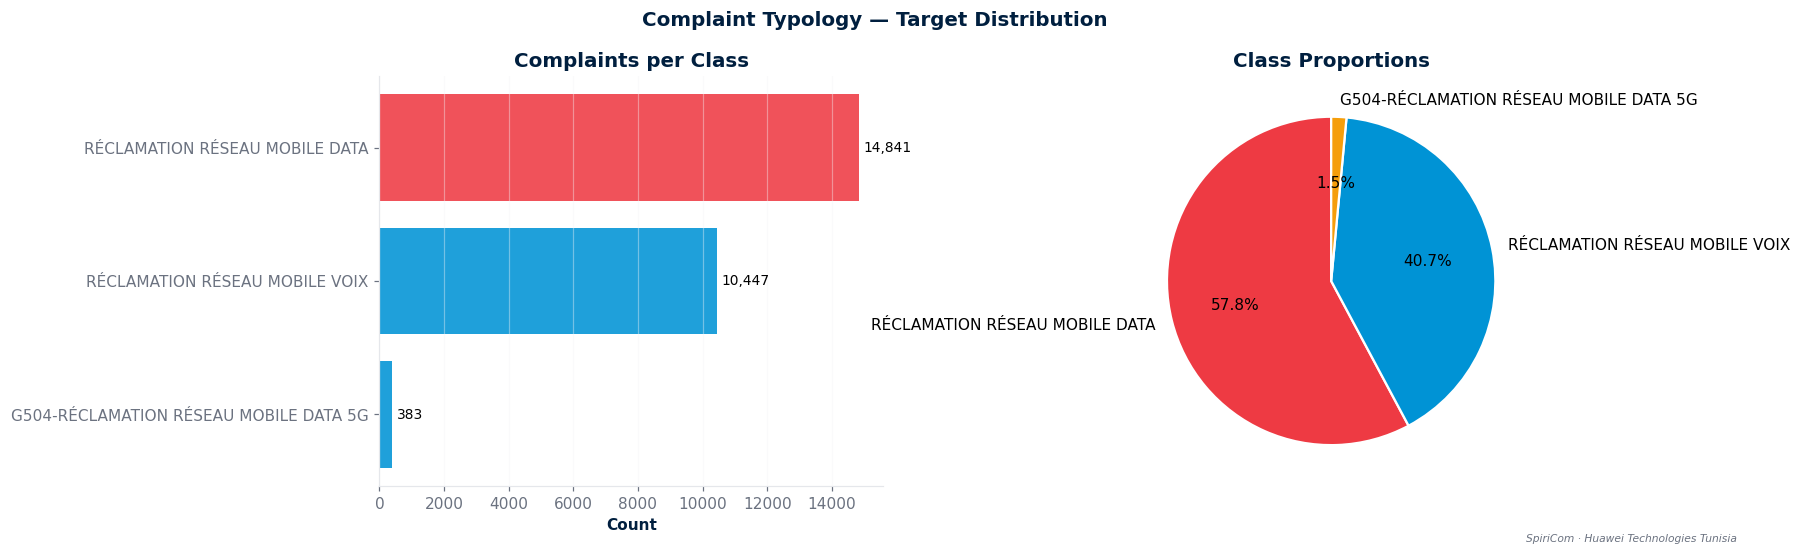

In [96]:
# ── 2.2  Encode target + train/test split ────────────────────────────
le_target = LabelEncoder()
y = le_target.fit_transform(df[TARGET_COL].astype(str))
X = df[FEATURE_COLS].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Class weights for imbalanced classes
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(zip(np.unique(y_train), cw))
sw_train = np.array([cw_dict[yi] for yi in y_train])

print(f'X: {X.shape}  |  Train: {len(X_train):,}  Test: {len(X_test):,}')
print(f'Classes ({len(le_target.classes_)}): {list(le_target.classes_)}')

# Visualise target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Complaint Typology — Target Distribution', fontsize=13,
             fontweight='bold', color=HW['navy'])

ax = axes[0]
dist2 = df[TARGET_COL].value_counts()
colors = [HW['red'] if i == 0 else HW['blue'] for i in range(len(dist2))]
ax.barh(dist2.index[::-1], dist2.values[::-1], color=colors[::-1], alpha=0.88)
for i, (idx, val) in enumerate(zip(dist2.index[::-1], dist2.values[::-1])):
    ax.text(val + dist2.max()*0.01, i, f'{val:,}', va='center', fontsize=9)
ax.set_title('Complaints per Class')
ax.set_xlabel('Count')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

ax = axes[1]
pal = [HW['red'],HW['blue'],HW['amber'],HW['green'],HW['purple'],HW['cyan'],'#F97316','#EC4899']
ax.pie(dist2.values, labels=dist2.index, colors=pal[:len(dist2)],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Class Proportions')

wm(fig); plt.tight_layout()
save_fig('fig08a_A_target_dist')
plt.show()

---
## §3 — Random Forest + XGBoost

In [97]:
# ── 3.1  Random Forest ───────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf    = rf.predict(X_test)
rf_acc       = accuracy_score(y_test, y_pred_rf)
rf_f1        = f1_score(y_test, y_pred_rf, average='macro',    zero_division=0)
rf_f1w       = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_report    = classification_report(
    y_test, y_pred_rf, target_names=le_target.classes_,
    output_dict=True, zero_division=0
)
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print(f'  RF  — Acc: {rf_acc:.4f}  F1-macro: {rf_f1:.4f}  CV: {cv_rf.mean():.4f}±{cv_rf.std():.4f}')

# ── 3.2  XGBoost ─────────────────────────────────────────────────────
print('Training XGBoost...')
n_cls = len(le_target.classes_)
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='mlogloss', verbosity=0, n_jobs=-1,
    objective='multi:softprob' if n_cls > 2 else 'binary:logistic',
    num_class=n_cls if n_cls > 2 else None,
)
xgb_clf.fit(X_train, y_train, sample_weight=sw_train,
            eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb   = xgb_clf.predict(X_test)
xgb_acc      = accuracy_score(y_test, y_pred_xgb)
xgb_f1       = f1_score(y_test, y_pred_xgb, average='macro',    zero_division=0)
xgb_f1w      = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
xgb_report   = classification_report(
    y_test, y_pred_xgb, target_names=le_target.classes_,
    output_dict=True, zero_division=0
)
cv_xgb = cross_val_score(
    xgb.XGBClassifier(n_estimators=100, max_depth=6, eval_metric='mlogloss',
                      random_state=42, n_jobs=-1, verbosity=0,
                      objective='multi:softprob' if n_cls>2 else 'binary:logistic',
                      num_class=n_cls if n_cls>2 else None),
    X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print(f'  XGB — Acc: {xgb_acc:.4f}  F1-macro: {xgb_f1:.4f}  CV: {cv_xgb.mean():.4f}±{cv_xgb.std():.4f}')

BEST = 'xgboost' if xgb_f1 >= rf_f1 else 'random_forest'
print(f'\n  → Best model: {BEST.upper()}')

Training Random Forest...
  RF  — Acc: 0.7036  F1-macro: 0.7898  CV: 0.7726±0.0030
Training XGBoost...
  XGB — Acc: 0.6987  F1-macro: 0.7881  CV: 0.7898±0.0036

  → Best model: RANDOM_FOREST


In [98]:
# ── 3b.  Results interpretation ───────────────────────────────────────
# Prints a structured analysis table ready for your PFE report.

print('=' * 60)
print('RESULTS INTERPRETATION — NB08a')
print('=' * 60)

# ── Baseline comparison ───────────────────────────────────────────
n_cls_actual = len(le_target.classes_)
baseline_random   = round(1 / n_cls_actual, 4)
baseline_majority = round(cc_clean[TARGET_COL].value_counts(normalize=True).max(), 4)

print(f'\nBaseline comparison ({n_cls_actual} classes):')
print(f'  Random guess         : {baseline_random:.4f}  (1 / {n_cls_actual})')
print(f'  Always-majority      : {baseline_majority:.4f}  (predict most common class)')
print(f'  RF  F1-macro         : {rf_f1:.4f}  '
      f'(+{rf_f1 - baseline_random:.4f} vs random)')
print(f'  XGB F1-macro         : {xgb_f1:.4f}  '
      f'(+{xgb_f1 - baseline_random:.4f} vs random)')

# ── Which model wins and why ──────────────────────────────────────
print(f'\nModel comparison:')
print(f'  RF  test F1-macro : {rf_f1:.4f}   RF  CV: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'  XGB test F1-macro : {xgb_f1:.4f}   XGB CV: {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')
if xgb_f1 >= rf_f1:
    print(f'  → XGB wins on test set')
elif cv_xgb.mean() > cv_rf.mean():
    print(f'  → RF wins on test set, XGB wins on CV (more stable generalisation)')
    print(f'    In production prefer XGB (CV is a better estimate of real-world perf)')
else:
    print(f'  → RF wins on both test set and CV')

# ── Per-class performance ─────────────────────────────────────────
print(f'\nPer-class F1 scores (best model: {BEST.upper()}):')
best_report = xgb_report if BEST == 'xgboost' else rf_report
class_rows = [
    (cls, best_report.get(cls, {}).get('f1-score', 0),
          best_report.get(cls, {}).get('support', 0))
    for cls in le_target.classes_
]
class_rows.sort(key=lambda x: x[1], reverse=True)
for cls, f1, sup in class_rows:
    bar    = '█' * int(f1 * 20)
    status = '✅' if f1 >= 0.70 else '⚠' if f1 >= 0.50 else '❌'
    print(f'  {status} {str(cls):<40s} F1={f1:.3f}  n={sup:5,}  {bar}')

low_f1 = [cls for cls, f1, _ in class_rows if f1 < 0.70]
if low_f1:
    print(f'\n  Classes below F1=0.70: {low_f1}')
    print(f'  → These sub-categories are harder to distinguish.')
    print(f'    Consider: merging similar classes, adding more features,')
    print(f'    or using sub_sub_category for finer granularity.')
else:
    print(f'\n  All classes above F1=0.70 ✅')

# ── Key insight for NOC ───────────────────────────────────────────
print(f'\nNOC RCA interpretation:')
print(f'  The model predicts complaint sub-category from:')
print(f'  province, segment, complaint_type, category, temporal features')
print(f'  → SHAP (next cell) shows which of these drives each sub-category')
print(f'  → E.g. if province is top SHAP driver: location is root cause')
print(f'         if segment drives it: customer type is root cause')
print(f'         if month/quarter drives it: seasonal/capacity issue')


RESULTS INTERPRETATION — NB08a

Baseline comparison (3 classes):
  Random guess         : 0.3333  (1 / 3)
  Always-majority      : 0.5781  (predict most common class)
  RF  F1-macro         : 0.7898  (+0.4565 vs random)
  XGB F1-macro         : 0.7881  (+0.4548 vs random)

Model comparison:
  RF  test F1-macro : 0.7898   RF  CV: 0.7726 ± 0.0030
  XGB test F1-macro : 0.7881   XGB CV: 0.7898 ± 0.0036
  → RF wins on test set, XGB wins on CV (more stable generalisation)
    In production prefer XGB (CV is a better estimate of real-world perf)

Per-class F1 scores (best model: RANDOM_FOREST):
  ✅ G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G   F1=0.993  n= 76.0  ███████████████████
  ✅ RÉCLAMATION RÉSEAU MOBILE DATA           F1=0.747  n=2,969.0  ██████████████
  ⚠ RÉCLAMATION RÉSEAU MOBILE VOIX           F1=0.629  n=2,090.0  ████████████

  Classes below F1=0.70: ['RÉCLAMATION RÉSEAU MOBILE VOIX']
  → These sub-categories are harder to distinguish.
    Consider: merging similar classes, adding mo

---
## §4 — SHAP Explainability

In [99]:
# ── SHAP shape helper (same as NB08b) ────────────────────────────────
# XGBoost returns different SHAP shapes depending on version:
#   (n_classes, n_samples, n_features)  older API
#   (n_samples, n_features, n_classes)  some builds
#   (n_samples, n_features)             binary
#   list of (n_samples, n_features)     legacy multi-class

def shap_to_1d(sv, n_features):
    arr = np.array(sv)
    if arr.ndim == 3:
        if arr.shape[2] == n_features:    # (n_cls, n_samp, n_feat)
            return np.abs(arr).mean(axis=(0, 1))
        elif arr.shape[1] == n_features:  # (n_samp, n_feat, n_cls)
            return np.abs(arr).mean(axis=(0, 2))
        elif arr.shape[0] == n_features:  # (n_feat, n_samp, n_cls) — rare
            return np.abs(arr).mean(axis=(1, 2))
        else:
            return np.abs(arr).reshape(-1, n_features).mean(axis=0)
    elif arr.ndim == 2:
        if arr.shape[1] == n_features:    # (n_samp, n_feat)
            return np.abs(arr).mean(axis=0)
        elif arr.shape[0] == n_features:  # (n_feat, n_samp)
            return np.abs(arr).mean(axis=1)
    if isinstance(sv, list):
        return np.mean([np.abs(np.array(s)).mean(axis=0) for s in sv], axis=0).flatten()
    return np.abs(arr).flatten()[:n_features]

def shap_per_class_list(sv, n_features, n_classes):
    arr = np.array(sv)
    if arr.ndim == 3 and arr.shape[2] == n_features:   # (n_cls, n_samp, n_feat)
        return [np.abs(arr[i]).mean(axis=0) for i in range(n_classes)]
    elif arr.ndim == 3 and arr.shape[1] == n_features: # (n_samp, n_feat, n_cls)
        return [np.abs(arr[:, :, i]).mean(axis=0) for i in range(n_classes)]
    elif isinstance(sv, list) and len(sv) == n_classes:
        return [np.abs(np.array(sv[i])).mean(axis=0) for i in range(n_classes)]
    return [shap_to_1d(sv, n_features)] * n_classes

print('✅ shap_to_1d + shap_per_class_list defined')


✅ shap_to_1d + shap_per_class_list defined


In [100]:
# ── 4.1  SHAP on XGBoost ─────────────────────────────────────────────
print('Computing SHAP values...')
X_shap    = X_test.iloc[:min(500, len(X_test))]
explainer = shap.TreeExplainer(xgb_clf)
shap_vals  = explainer.shap_values(X_shap)

n_feat = len(FEATURE_COLS)
n_cls  = len(le_target.classes_)

shap_global = shap_to_1d(shap_vals, n_feat)
assert len(shap_global) == n_feat, \
    f'SHAP length {len(shap_global)} != features {n_feat} — check shap_to_1d'

shap_df = pd.DataFrame({'feature': FEATURE_COLS, 'shap_mean': shap_global})\
           .sort_values('shap_mean', ascending=False).reset_index(drop=True)

# ── 4.2  Per-class SHAP ───────────────────────────────────────────────
per_class_arrays = shap_per_class_list(shap_vals, n_feat, n_cls)
per_class_shap   = {}
print(f'\nTop SHAP driver per complaint class:')
for i, cls in enumerate(le_target.classes_):
    sv_cls = per_class_arrays[i]
    top    = sorted(zip(FEATURE_COLS, sv_cls), key=lambda x: x[1], reverse=True)[:5]
    per_class_shap[cls] = [{'feature': f, 'shap': round(float(v), 6)} for f, v in top]
    print(f'  {str(cls):<40s} → {top[0][0]} ({top[0][1]:.4f})')

print(f'\nTop 10 global SHAP drivers:')
shap_max = shap_df.shap_mean.max() if shap_df.shap_mean.max() > 0 else 1.0
for _, row in shap_df.head(10).iterrows():
    bar = chr(9608) * int(row.shap_mean / shap_max * 25)
    print(f'  {row.feature:<35s}: {row.shap_mean:.5f}  {bar}')


Computing SHAP values...

Top SHAP driver per complaint class:
  G504-RÉCLAMATION RÉSEAU MOBILE DATA 5G   → enc_category (3.0396)
  RÉCLAMATION RÉSEAU MOBILE DATA           → is_unresolved (0.4700)
  RÉCLAMATION RÉSEAU MOBILE VOIX           → is_unresolved (0.4585)

Top 10 global SHAP drivers:
  enc_category                       : 1.27561  █████████████████████████
  week_num                           : 0.57716  ███████████
  enc_province                       : 0.38390  ███████
  day_of_week                        : 0.32719  ██████
  is_unresolved                      : 0.32310  ██████
  enc_segment                        : 0.28307  █████
  month                              : 0.09034  █
  quarter                            : 0.01518  
  enc_complaint_type                 : 0.00000  


  Saved: data\outputs\figures\fig08a_C_confusion.png


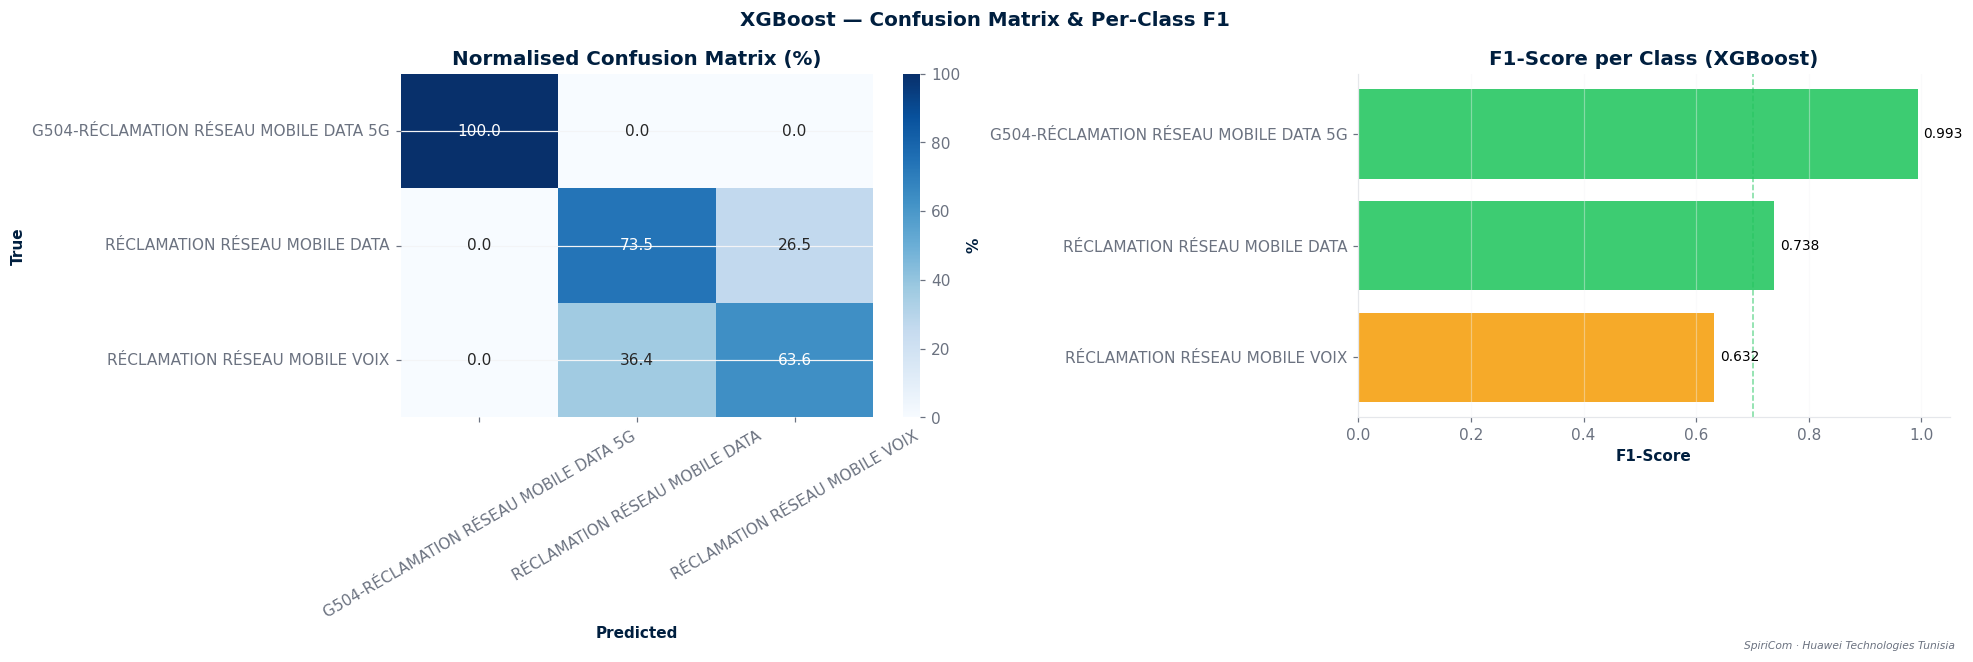

In [101]:
# ── 4.4  Confusion matrix ─────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred_xgb)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('XGBoost — Confusion Matrix & Per-Class F1',
             fontsize=13, fontweight='bold', color=HW['navy'])

ax = axes[0]
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            ax=ax, cbar_kws={'label':'%'})
ax.set_title('Normalised Confusion Matrix (%)')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
class_f1 = [xgb_report.get(c, {}).get('f1-score', 0) for c in le_target.classes_]
bar_c    = [HW['green'] if f >= 0.7 else HW['amber'] if f >= 0.5 else HW['red']
            for f in class_f1]
bars = ax.barh(le_target.classes_[::-1], class_f1[::-1],
               color=bar_c[::-1], alpha=0.88)
for bar, val in zip(bars, class_f1[::-1]):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.axvline(0.7, color=HW['green'], lw=1, ls='--', alpha=0.6)
ax.set_xlim(0, 1.05)
ax.set_title('F1-Score per Class (XGBoost)')
ax.set_xlabel('F1-Score')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

wm(fig); plt.tight_layout()
save_fig('fig08a_C_confusion')
plt.show()

---
## §5 — Save Artifacts

In [103]:
    shap_max = shap_df.shap_mean.max() if shap_df.shap_mean.max() > 0 else 1.0
    bar = '█' * int(row.shap_mean / shap_max * 20)


---
> **Next:** Run `08b_RootCauseAnalysis_5G.ipynb` for the Dataset 2 (subscriber KPI) 5G root cause analysis.
> These two notebooks are **independent** — they share no data and output to different keys in the dashboard.